# Question 5

**Replicating Long & Ervin (2000) Figure 2**


In [7]:
# Step 1: Generate the Population 
import numpy as np
from numpy.linalg import inv

np.random.seed(42)
N_pop = 100000

# Generating base variables
d1 = np.random.uniform(0, 1, N_pop)
d2 = np.random.normal(0, 1, N_pop)
d3 = np.random.chisquare(1, N_pop)
d4 = np.random.normal(0, 1, N_pop)
d5 = np.random.uniform(0, 1, N_pop)

# Constructing covariates
x1 = 1 + d1
x2 = 3*d1 + 0.6*d2
x3 = 2*d1 + 0.6*d3
x4 = 0.1*d1 + 0.9*d3 - 0.8*d4 + 4*d5

# Design matrix with intercept value
X_pop = np.column_stack([np.ones(N_pop), x1, x2, x3, x4])

# Using defined error structure 2
eps_star = np.random.chisquare(5, N_pop)
eps = np.sqrt(x3 + 1.6) * eps_star

y_signal = 1 + x1 + x2 + x3
var_signal = np.var(y_signal)
var_eps   = np.var(eps)
target_R2 = 0.5
tau = np.sqrt(var_signal / var_eps * (1/target_R2 - 1))
print(f"tau = {tau:.4f}")


y_pop = y_signal + tau * eps
beta_pop = inv(X_pop.T @ X_pop) @ X_pop.T @ y_pop
y_hat_pop = X_pop @ beta_pop
SS_res = np.sum((y_pop - y_hat_pop)**2)
SS_tot = np.sum((y_pop - np.mean(y_pop))**2)
R2_pop = 1 - SS_res/SS_tot
print(f"Population R^2 = {R2_pop:.4f}")
print(f"Population beta* = {beta_pop}")

tau = 0.3466
Population R^2 = 0.6049
Population beta* = [ 3.21947880e+00  1.09004647e+00  1.01091332e+00  1.43244393e+00
 -1.37737592e-04]


In [8]:
# Step 2: Implement SE Estimators
def compute_ses(X, y):
    """
    Returns dict of SEs for OLS, HC0, HC1, HC2, HC3.
    """
    N, K = X.shape
    XtXinv = inv(X.T @ X)
    beta_hat = XtXinv @ X.T @ y
    e = y - X @ beta_hat

    H_diag = np.einsum('ij,jk,ik->i', X, XtXinv, X)

    # OLS 
    sigma2 = (e @ e) / (N - K)
    V_ols = sigma2 * XtXinv

    # HC0
    meat_hc0 = (X * e[:, None]).T @ (X * e[:, None])
    V_hc0 = XtXinv @ meat_hc0 @ XtXinv

    # HC1
    V_hc1 = (N / (N - K)) * V_hc0

    # HC2
    e_hc2 = e / np.sqrt(1 - H_diag)
    meat_hc2 = (X * e_hc2[:, None]).T @ (X * e_hc2[:, None])
    V_hc2 = XtXinv @ meat_hc2 @ XtXinv

    # HC3
    e_hc3 = e / (1 - H_diag)
    meat_hc3 = (X * e_hc3[:, None]).T @ (X * e_hc3[:, None])
    V_hc3 = XtXinv @ meat_hc3 @ XtXinv

    return {
        'ols': np.sqrt(np.diag(V_ols)),
        'hc0': np.sqrt(np.diag(V_hc0)),
        'hc1': np.sqrt(np.diag(V_hc1)),
        'hc2': np.sqrt(np.diag(V_hc2)),
        'hc3': np.sqrt(np.diag(V_hc3)),
    }

# Sanity check 
import statsmodels.api as sm

idx = np.random.choice(N_pop, 100, replace=False)
X_test, y_test = X_pop[idx], y_pop[idx]

ses = compute_ses(X_test, y_test)

model = sm.OLS(y_test, X_test).fit()
hc3_sm = model.get_robustcov_results(cov_type='HC3')

print("Our HC3 SEs:", ses['hc3'])
print("statsmodels HC3 SEs:", hc3_sm.bse)

Our HC3 SEs: [1.41882138 1.37583259 0.37235866 0.48104487 0.16488547]
statsmodels HC3 SEs: [1.41882138 1.37583259 0.37235866 0.48104487 0.16488547]


In [9]:
# Step 3: One Replication
from scipy.stats import t as t_dist

def one_rep(N, X_pop, y_pop, beta_star, alpha=0.05):
    """
    Draw one sample of size N, compute reject/no-reject for each 
    pair at significance level alpha.
    Returns array of shape (5_estimators, K_coefficients).
    """
   
    idx = np.random.choice(len(y_pop), N, replace=False)
    X_s, y_s = X_pop[idx], y_pop[idx]

    N_s, K = X_s.shape
    beta_hat = inv(X_s.T @ X_s) @ X_s.T @ y_s

    ses = compute_ses(X_s, y_s)

    crit = t_dist.ppf(1 - alpha/2, df=N_s - K)

    results = {}
    for name, se in ses.items():
        t_stats = (beta_hat - beta_star) / se
        results[name] = (np.abs(t_stats) > crit).astype(int)

    return results

In [10]:
# Step 4: Monte Carlo Loop
sample_sizes = [25, 50, 100, 250, 500, 1000]
n_reps = 1000
estimators = ['ols', 'hc0', 'hc1', 'hc2', 'hc3']
K = X_pop.shape[1]  

rejection_rates = {est: np.zeros((len(sample_sizes), K)) for est in estimators}

for i, N in enumerate(sample_sizes):
    print(f"Running N = {N}")
    accum = {est: np.zeros(K) for est in estimators}

    for _ in range(n_reps):
        res = one_rep(N, X_pop, y_pop, beta_pop)
        for est in estimators:
            accum[est] += res[est]

    for est in estimators:
        rejection_rates[est][i] = accum[est] / n_reps


Running N = 25
Running N = 50
Running N = 100
Running N = 250
Running N = 500
Running N = 1000


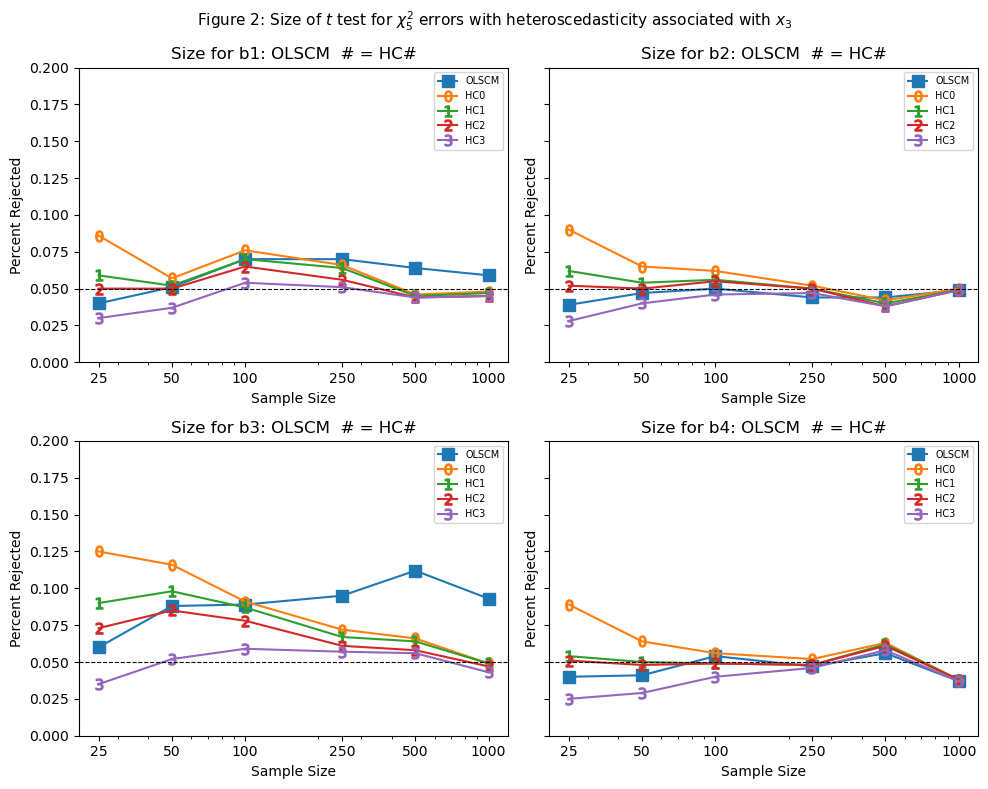

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

coef_labels = ['b1', 'b2', 'b3', 'b4']
coef_indices = [1, 2, 3, 4] 

markers = {'ols': 's', 'hc0': '$0$', 'hc1': '$1$', 'hc2': '$2$', 'hc3': '$3$'}
labels  = {'ols': 'OLSCM', 'hc0': 'HC0', 'hc1': 'HC1', 'hc2': 'HC2', 'hc3': 'HC3'}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for panel, (ax, k_idx, label) in enumerate(zip(axes, coef_indices, coef_labels)):
    for est in estimators:
        rates = rejection_rates[est][:, k_idx]
        ax.plot(sample_sizes, rates, marker=markers[est], label=labels[est], markersize=8)

    ax.axhline(0.05, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'Size for {label}: OLSCM  # = HC#')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Percent Rejected')
    ax.set_xscale('log')
    ax.set_xticks(sample_sizes)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 0.20)
    ax.legend(fontsize=7)

plt.suptitle(r'Figure 2: Size of $t$ test for $\chi^2_5$ errors with heteroscedasticity associated with $x_3$',
             fontsize=11)
plt.tight_layout()
plt.show()

OLSCM shows persistent and growing size distortion for Beta 3 as N increases, it never self-corrects under heteroscedasticity. HC0 over-rejects badly at small N. HC3 is slightly conservative at small N but converges cleanly to 0.05, making it the safest
default choice. The Beta 4 panel behaves well across all estimators (as expected, since x4 is unrelated to the heteroscedasticity structure).

This confirms Long & Ervin's recommendation: use HC3 routinely, especially when N < 250.

**Acknowledgement: plotting code for Figure 2 was done with AI assistance to ensure clean formatting.**